# 01 — Deployment Problem and Environment Drift

Goal: understand why deployment exists and why environment mismatch breaks ML systems.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'pipeline').exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / 'pipeline').exists():
            PROJECT_ROOT = parent
            break
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)

Project root: /home/ahmad/AI/Github/40 AI-ML Projects for Beginners/MLOps, UI, and Deployment/Deploy a Machine Learning Model with Docker


## 1.1 What Is Deployment?
**Definition:** Deployment is process of moving trained model into reliable inference service.

**Theory:** Explain mechanism, assumptions, and where this fits in deployment lifecycle.

**Motivation:** Why this matters for reliability, reproducibility, and operations.

**Real-World Example:** Data scientist shares model file but production pod uses mismatched package versions and crashes on startup.

**Visual Explanation:** See figure/code cell below.

**Code Explanation:** Code cell demonstrates concrete implementation details.

**Best Practices:** Treat deployment as software engineering, not final notebook step.

**Common Mistakes:** Copying model artifact without versioned runtime contract.

Saved: outputs/figures/deployment-problem-flow.png


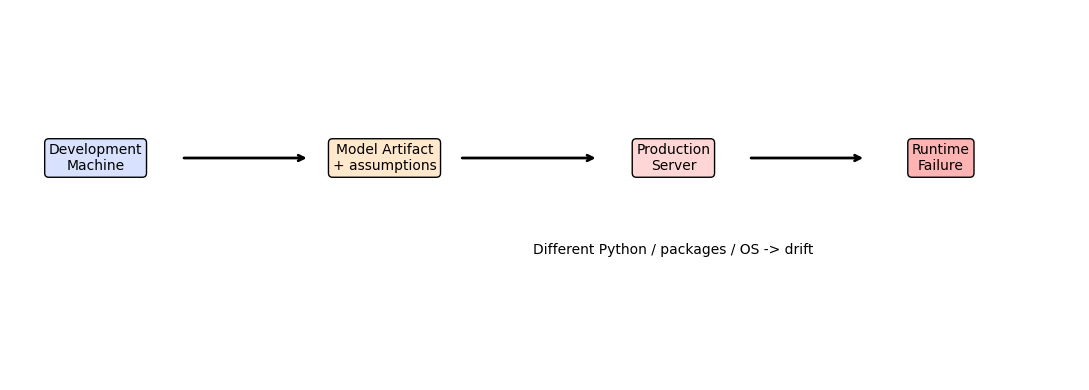

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

out = Path('outputs/figures')
out.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off')
ax.text(0.08, 0.6, 'Development\nMachine', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='#d8e2ff'))
ax.text(0.35, 0.6, 'Model Artifact\n+ assumptions', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='#ffe8cc'))
ax.text(0.62, 0.6, 'Production\nServer', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='#ffd6d6'))
ax.text(0.87, 0.6, 'Runtime\nFailure', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='#ffb3b3'))
ax.annotate('', xy=(0.28, 0.6), xytext=(0.16, 0.6), arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(0.55, 0.6), xytext=(0.42, 0.6), arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(0.8, 0.6), xytext=(0.69, 0.6), arrowprops=dict(arrowstyle='->', lw=2))
ax.text(0.62, 0.34, 'Different Python / packages / OS -> drift', ha='center')
plt.tight_layout()
fig.savefig(out / 'deployment-problem-flow.png', dpi=150)
print('Saved:', out / 'deployment-problem-flow.png')

## 1.2 Environment Drift and Dependency Conflicts
**Definition:** Environment drift is runtime difference between training and serving environments.

**Theory:** Explain mechanism, assumptions, and where this fits in deployment lifecycle.

**Motivation:** Why this matters for reliability, reproducibility, and operations.

**Real-World Example:** Notebook uses sklearn/xgboost versions that differ from production container image.

**Visual Explanation:** See figure/code cell below.

**Code Explanation:** Code cell demonstrates concrete implementation details.

**Best Practices:** Pin versions, freeze environment, containerize runtime.

**Common Mistakes:** Using latest tags with no lock file or reproducible build.

In [3]:
import platform
import sys
import sklearn
import fastapi
import numpy

print('Python:', sys.version)
print('Platform:', platform.platform())
print('scikit-learn:', sklearn.__version__)
print('fastapi:', fastapi.__version__)
print('numpy:', numpy.__version__)

Python: 3.12.10 (main, May 30 2025, 05:37:37) [Clang 20.1.4 ]
Platform: Linux-7.0.0-22-generic-x86_64-with-glibc2.43
scikit-learn: 1.4.2
fastapi: 0.138.0
numpy: 1.26.4


## Summary
Deployment solves reproducibility and operational reliability. Next notebook moves into Docker fundamentals.